# Data Cleaning & Feature Engineering
**Project:** Student Performance Predictor  
**Goal:** Clean the data, handle missing values, engineer features, 
and merge all three tables into one flat feature table ready for modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
student_info = pd.read_csv("../data/raw/studentInfo.csv")
student_assessment = pd.read_csv("../data/raw/studentAssessment.csv")
student_Vle = pd.read_csv("../data/raw/studentVle.csv")
assessments = pd.read_csv("../data/raw/assessments.csv")
courses = pd.read_csv("../data/raw/courses.csv")

In [3]:
student_info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn


In [4]:
student_info.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [5]:
(student_info.isnull().sum()/len(student_info)* 100).round(2)

code_module             0.00
code_presentation       0.00
id_student              0.00
gender                  0.00
region                  0.00
highest_education       0.00
imd_band                3.41
age_band                0.00
num_of_prev_attempts    0.00
studied_credits         0.00
disability              0.00
final_result            0.00
dtype: float64

In [6]:
student_info["imd_band"].unique

<bound method Series.unique of 0        90-100%
1         20-30%
2         30-40%
3         50-60%
4         50-60%
          ...   
32588      10-20
32589     40-50%
32590     20-30%
32591    90-100%
32592     50-60%
Name: imd_band, Length: 32593, dtype: str>

In [7]:
# REPLACING ALL MISSING VALUES OF THE IMD_BAND WITH THE MODE OF THE IMD_COLUMN

student_info["imd_band"].mode()[0]

'20-30%'

In [8]:
student_info["imd_band"] = student_info["imd_band"].fillna('20-30%')

In [9]:
student_info.isnull().sum()

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64

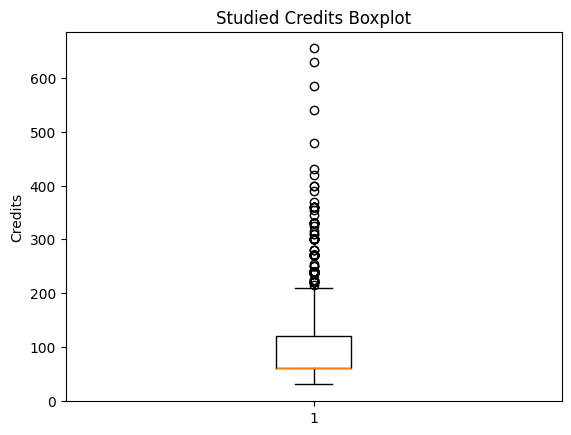

In [10]:
# DEALING WITH OUTLIERS IN THE STUDIED_CREDITS COLUMN 

plt.boxplot(student_info['studied_credits'])
plt.title('Studied Credits Boxplot')
plt.ylabel('Credits')
plt.show()

In [11]:
# CAPPING: REDUCING OUTLIERS TO A MAXIMUM THRESHOLD USING CLIP FUNCTION INSTEAD OF JUST TAKING AWAY ALL THE OUTLIERS 

student_info["studied_credits"] = student_info["studied_credits"].clip(upper= 300)

"studied_credits capped at 300 based on EDA observation that only 35 students (0.1%) exceeded this value. IQR method not applied — to be revisited if model performance is poor."

In [12]:
student_info["studied_credits"].max()

np.int64(300)

In [13]:
# WORKING WITH THE TARGET VARIABLE, WHICH IS FINAL_RESULT

student_info["final_result"].unique()

<StringArray>
['Pass', 'Withdrawn', 'Fail', 'Distinction']
Length: 4, dtype: str

In [14]:
student_info["at_risk"] = student_info["final_result"].map({"Pass":0, "Distinction" :0, "Withdrawn":1, "Fail": 1})

In [15]:
student_info["at_risk"].value_counts()

at_risk
1    17208
0    15385
Name: count, dtype: int64

In [16]:
# CHECKING FOR A SAMPLE, IF THE FINAL_RESULT AND AT_RISK COLUMNS MATCH
student_info[["final_result", "at_risk"]].sample(10)

,final_result,at_risk
13741,Fail,1
4626,Distinction,0
8920,Pass,0
2661,Pass,0
23578,Fail,1
16715,Withdrawn,1
4671,Pass,0
1943,Withdrawn,1
2168,Pass,0
1999,Pass,0


In [17]:
pd.crosstab(student_info["imd_band"], student_info["final_result"], normalize= "index").mul(100).round(1)

final_result,Distinction,Fail,Pass,Withdrawn
imd_band,,,,
0-10%,5.1,27.7,30.1,37.2
10-20,5.4,25.9,33.2,35.4
20-30%,9.7,20.8,36.9,32.7
30-40%,8.9,22.2,38.0,30.9
40-50%,9.0,21.4,37.6,32.0
50-60%,9.5,22.4,39.3,28.8
60-70%,10.3,18.5,41.6,29.6
70-80%,10.9,20.8,40.6,27.7
80-90%,11.9,17.9,42.2,28.0


"imd_band shows a 22 percentage point gap in At Risk rates between most deprived (0-10%) and least deprived (90-100%) students. Confirmed as a useful feature."

In [18]:
student_info.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'at_risk'],
      dtype='str')

In [19]:
pd.crosstab(student_info["disability"], student_info["final_result"], normalize= "index").mul(100).round(1)

final_result,Distinction,Fail,Pass,Withdrawn
disability,,,,
N,9.5,21.5,38.7,30.3
Y,7.0,22.5,31.1,39.3


In [20]:
pd.crosstab(student_info["region"], student_info["final_result"], normalize= "index").mul(100).round(1)

final_result,Distinction,Fail,Pass,Withdrawn
region,,,,
East Anglian Region,9.8,20.9,39.2,30.1
East Midlands Region,8.5,19.5,37.3,34.8
Ireland,8.3,22.0,46.6,23.1
London Region,8.2,23.1,34.2,34.5
North Region,12.6,17.9,37.9,31.5
North Western Region,7.3,24.2,32.9,35.6
Scotland,9.5,24.7,39.4,26.3
South East Region,11.6,17.8,39.9,30.7
South Region,10.8,17.6,41.6,30.0


ALL COLUMNS OF THE STUDENT_INFO DATA TABLE ARE ESSENTIAL, BUT THE FOLLOWING COLUMNS CAN BE DROPPED: code_module, code_presentation, id_student, final_result because it is replaced by at_risk column

In [21]:
# CHECKING FOR CATEGORICAL COLUMNS WHICH HAVE A NATURAL ORDER SO IT CAN BE ENCODED, EITHER LABEL OR ONE HOT ENCODING
student_info["age_band"].unique()

<StringArray>
['55<=', '35-55', '0-35']
Length: 3, dtype: str

In [22]:
student_info["imd_band"].unique()

<StringArray>
['90-100%',  '20-30%',  '30-40%',  '50-60%',  '80-90%',  '70-80%',  '60-70%',
  '40-50%',   '10-20',   '0-10%']
Length: 10, dtype: str

In [23]:
student_info["highest_education"].unique()

<StringArray>
[           'HE Qualification',       'A Level or Equivalent',
          'Lower Than A Level', 'Post Graduate Qualification',
             'No Formal quals']
Length: 5, dtype: str

THESE THREE COLUMNS ARE ORDINAL COLUMNS, THE REMAINING CATEGORICAL COLUMNS WILL BE ONE HOT ENCODED, BUT FOR NOW LETS DEFINE THE ORDER FOR THE ORDINAL COLUMNS

In [24]:
education_order = {
    "No Formal quals" : 0,
    "Lower Than A Level" : 1,
    'A Level or Equivalent' : 2,
    'HE Qualification' : 3,
    'Post Graduate Qualification' : 4
}

student_info["highest_education"] = student_info["highest_education"].map(education_order)

In [25]:
student_info["highest_education"].value_counts()

highest_education
2    14045
1    13158
3     4730
0      347
4      313
Name: count, dtype: int64

In [26]:
age_order = {
    '0-35': 0,
    '35-55' : 1,
    '55<=' : 2
}

student_info["age_band"] = student_info["age_band"].map(age_order)

In [27]:
student_info["age_band"].value_counts()

age_band
0    22944
1     9433
2      216
Name: count, dtype: int64

In [28]:
imd_order = {
    '0-10%' : 0,
    '10-20': 1,
    '20-30%': 2,
    '30-40%': 3,
    '40-50%' : 4,
    '50-60%' : 5,
    '60-70%' : 6,
    '70-80%' : 7,
    '80-90%' : 8,
    '90-100%': 9
}

student_info["imd_band"] = student_info["imd_band"].map(imd_order)

In [29]:
student_info["imd_band"].value_counts()

imd_band
2    4765
3    3539
1    3516
0    3311
4    3256
5    3124
6    2905
7    2879
8    2762
9    2536
Name: count, dtype: int64

In [30]:
# ONE HOT ENCODING THE NOMINAL COLUMNS
student_info = pd.get_dummies(student_info, columns= ["gender", "disability", "region"])

In [31]:
student_info

,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,at_risk,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,AAA,2013J,11391,3,9,2,0,240,Pass,0,...,False,False,False,False,False,False,False,False,False,False
1,AAA,2013J,28400,3,2,1,0,60,Pass,0,...,False,False,False,True,False,False,False,False,False,False
2,AAA,2013J,30268,2,3,1,0,60,Withdrawn,1,...,False,False,True,False,False,False,False,False,False,False
3,AAA,2013J,31604,2,5,1,0,60,Pass,0,...,False,False,False,False,True,False,False,False,False,False
4,AAA,2013J,32885,1,5,0,0,60,Pass,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,1,1,0,0,30,Fail,1,...,False,False,False,False,False,False,False,True,False,False
32589,GGG,2014J,2645731,1,4,1,0,30,Distinction,0,...,False,False,False,False,False,False,False,False,False,False
32590,GGG,2014J,2648187,2,2,0,0,30,Pass,0,...,False,False,False,False,False,True,False,False,False,False
32591,GGG,2014J,2679821,1,9,1,0,30,Withdrawn,1,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
# INSTEAD OF DROPPING SOME COLUMNS, WE MAKE HAVE NEED OF LATER, WE WOULD JUST SELECT THE COLUMNS WE NEED INTO A NEW TABLE

regional_columns = [col for col in student_info.columns if col.startswith("region_")]

selected_columns = ["code_module", "code_presentation", "id_student", "highest_education", "imd_band", "age_band", "num_of_prev_attempts", "studied_credits", "at_risk"] + regional_columns
student_features = student_info[selected_columns]

In [38]:
print(student_features.shape)

(32593, 22)


In [39]:
student_features.head()

,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,at_risk,region_East Anglian Region,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,AAA,2013J,11391,3,9,2,0,240,0,True,...,False,False,False,False,False,False,False,False,False,False
1,AAA,2013J,28400,3,2,1,0,60,0,False,...,False,False,False,True,False,False,False,False,False,False
2,AAA,2013J,30268,2,3,1,0,60,1,False,...,False,False,True,False,False,False,False,False,False,False
3,AAA,2013J,31604,2,5,1,0,60,0,False,...,False,False,False,False,True,False,False,False,False,False
4,AAA,2013J,32885,1,5,0,0,60,0,False,...,False,False,False,False,False,False,False,False,True,False


In [40]:
# SAVING THE STUDENT_FEATURES TABLE TO THE PROCESSED FOLDER
student_features.to_csv("../data/processed/student_features.csv", index = False)

In [41]:
import os
os.path.exists("../data/processed/student_features.csv")

True

In [42]:
# MOVING ON TO THE NEXT DATA TABLE: STUDENT_ASSESSMENT

student_assessment

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
...,...,...,...,...,...
173907,37443,527538,227,0,60.0
173908,37443,534672,229,0,100.0
173909,37443,546286,215,0,80.0
173910,37443,546724,230,0,100.0


In [ ]:
# FOR EVERYWHERE IS_BANKED IS 1, INPUT SCORE = 0, MEANING THEY DID NOT HAVE A REAL SCORE 
student_assessment.loc[student_assessment["is_banked"] == 1, "score"] = 0

In [44]:
# VERIFICATION
student_assessment[student_assessment["is_banked"] == 1]["score"].isnull().sum()

np.int64(0)

In [45]:
student_assessment

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
...,...,...,...,...,...
173907,37443,527538,227,0,60.0
173908,37443,534672,229,0,100.0
173909,37443,546286,215,0,80.0
173910,37443,546724,230,0,100.0


We have to merge the student_assesssment table with the assessment table to be able to calculate the mean of scores we can use to replace the missing scores beacuse note that the student_assessment table contains  different scores for different students and one student can take more than one row.To get the accurate mean we must group them by the student_id, the code_module and code_presentation.

In [46]:
assessments

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0
...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229.0,0.0
202,GGG,2014J,37435,TMA,61.0,0.0
203,GGG,2014J,37436,TMA,124.0,0.0
204,GGG,2014J,37437,TMA,173.0,0.0


"assessment_type has three values: TMA, CMA, and Exam. Exam type will be excluded from features as it occurs at the end of the module — too late to intervene." A good filter

In [47]:
# MERGING THE STUDENT_ASSESSMENT COLUMN WITH THE ASSESSMENT COLUMN
student_assessment = student_assessment.merge(
    assessments,
    on= "id_assessment",
    how= "left"
)

In [49]:
student_assessment.shape

(173912, 10)

In [50]:
student_assessment.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0


In [51]:
student_assessment["score"] = student_assessment["score"].fillna(
    student_assessment.groupby(["code_module", "code_presentation", "id_assessment"])["score"].transform("mean")
    )

In [52]:
student_assessment["score"].isnull().sum()

np.int64(0)

In [ ]:
# FILTERING FOR EARLY ASSESSMENTS, ASSESSMENTS SUBMITTED WITHIN THE FIRST 90 DAYS OF THE MODULE

student_assessment["date"].describe()

count    171047.000000
mean        130.605623
std          78.025175
min          12.000000
25%          54.000000
50%         129.000000
75%         214.000000
max         261.000000
Name: date, dtype: float64

In [54]:
early_assessments = student_assessment[student_assessment["date"] <= 90]

In [58]:
print(f"early_assessments : {len(early_assessments)}")
print(f"total_assessments : {len(student_assessment)}")
print(f"percentage : {len(early_assessments)/ len(student_assessment) * 100}.round(1)%")

early_assessments : 64701
total_assessments : 173912
percentage : 37.203298219789325.round(1)%


In [59]:
# NOW WE HAVE TO FILTER OUT THE EXAM TYPE ASSESSMENT BECAUSE EXAMINATIONS RUN AT THE END OF THE SEMESTER OF MODULE AND ISNT SUITABLE FOR THE EARLY ASSESSMENTS 
early_assessments

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0
...,...,...,...,...,...,...,...,...,...,...
170120,37435,541774,60,0,56.0,GGG,2014J,TMA,61.0,0.0
170121,37435,546286,60,0,69.0,GGG,2014J,TMA,61.0,0.0
170122,37435,546724,59,0,75.0,GGG,2014J,TMA,61.0,0.0
170123,37435,547334,59,0,54.0,GGG,2014J,TMA,61.0,0.0


In [60]:
early_assessments["assessment_type"].unique()

<StringArray>
['TMA', 'CMA']
Length: 2, dtype: str

However from this output, we could see that all exam assessment type didnt even make it to the early assessment. Profound...The code is below just in case.

In [61]:
early_assessments = early_assessments[early_assessments["assessment_type"] != "Exam"]

In [62]:
assessment_features = early_assessments.groupby(["id_student", "code_module", "code_presentation"]).agg(
    mean_score = ("score", "mean"),
    max_score = ("score", "max"),
    min_score = ("score", "min"),
    number_of_takes = ("score", "count"),
    mean_weight = ("weight", "mean")
).reset_index()

In [63]:
assessment_features

,id_student,code_module,code_presentation,mean_score,max_score,min_score,number_of_takes,mean_weight
0,6516,AAA,2014J,54.000000,60.0,48.0,2,15.000000
1,8462,DDD,2013J,87.666667,93.0,83.0,3,13.333333
2,8462,DDD,2014J,0.000000,0.0,0.0,3,8.333333
3,11391,AAA,2013J,81.500000,85.0,78.0,2,15.000000
4,23629,BBB,2013B,82.500000,100.0,63.0,4,6.250000
...,...,...,...,...,...,...,...,...
25718,2698257,AAA,2013J,61.000000,64.0,58.0,2,15.000000
25719,2698535,CCC,2014B,30.500000,41.0,20.0,2,4.500000
25720,2698535,EEE,2013J,59.500000,61.0,58.0,2,22.000000
25721,2698577,BBB,2014J,77.000000,100.0,54.0,2,5.000000


In [65]:
assessment_features.shape

(25723, 8)

In [66]:
assessment_features.to_csv("../data/processed/assessment_features.csv", index = "False")

In [68]:
os.path.exists("../data/processed/assessment_features.csv")

True